# Study Single Particle Decay Chain with Different Energy Thresholds

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
# from utils import load_root_file, load_hepmc_event
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from clustering_metrics import evaluate_clustering, plot_clustering_metrics

from edm4hep_utils import pixel_readouts, strip_readouts
all_tracker_readouts = pixel_readouts + strip_readouts

## Roadmap

1. Load in 3 edm4hep files
2. Visualize hits in one event in all three subdetectors
3. Inspect number of particles in each working point
4. Trace decay chain for each working point

# Loading

In [141]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV"
event_num = 0

## 1. Load in edm4hep file

In [142]:
low_threshold_edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"
medium_threshold_edm4hep_file = f"{base_dir}/single_run_test_medium_threshold/edm4hep.root"
high_threshold_edm4hep_file = f"{base_dir}/single_run_test_high_threshold/edm4hep.root"

low_threshold_event = load_edm4hep_file(low_threshold_edm4hep_file, event_num=event_num)
medium_threshold_event = load_edm4hep_file(medium_threshold_edm4hep_file, event_num=event_num)
high_threshold_event = load_edm4hep_file(high_threshold_edm4hep_file, event_num=event_num)

In [143]:
low_threshold_event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [144]:
low_tracker_df = low_threshold_event["tracker_df"]
medium_tracker_df = medium_threshold_event["tracker_df"]
high_tracker_df = high_threshold_event["tracker_df"]
low_tracker_df.columns

Index(['cellID', 'EDep', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px',
       'py', 'pz', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [145]:
low_parents_df = low_threshold_event["parents_df"]
medium_parents_df = medium_threshold_event["parents_df"]
high_parents_df = high_threshold_event["parents_df"]

low_daughters_df = low_threshold_event["daughters_df"]
medium_daughters_df = medium_threshold_event["daughters_df"]
high_daughters_df = high_threshold_event["daughters_df"]

low_particles_df = low_threshold_event["particles_df"]
medium_particles_df = medium_threshold_event["particles_df"]
high_particles_df = high_threshold_event["particles_df"]

# Create a column from the index
low_particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [146]:
low_calo_hits_df = low_threshold_event["calo_hits_df"]
medium_calo_hits_df = medium_threshold_event["calo_hits_df"]
high_calo_hits_df = high_threshold_event["calo_hits_df"]
low_calo_hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [147]:
low_calo_contrib_df = low_threshold_event["calo_contrib_df"]
medium_calo_contrib_df = medium_threshold_event["calo_contrib_df"]
high_calo_contrib_df = high_threshold_event["calo_contrib_df"]
low_calo_contrib_df.columns


Index(['PDG', 'energy', 'time', 'step_x', 'step_y', 'step_z', 'particle_id',
       'x', 'y', 'z', 'detector'],
      dtype='object')

## Visualize hits in one event in all three subdetectors

In [148]:
low_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,211,1,150994944,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,215.503582,-1053.953214,0,0,0,25,7.509689,10.000000,-0.793412,0.228517
1,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314567,-558.626150,0.002685,...,131.401366,-581.983508,0,1,25,25,0.003212,0.003374,-0.316664,0.580828
2,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,2.335005,...,306.682803,-1544.734026,1,2,25,25,2.396004,3.456059,-0.909041,0.226132
3,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,1.061720,...,205.171274,-1123.123427,2,3,25,38,1.067991,1.306458,-0.656411,-0.108426
4,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.548697,...,118.435793,-1018.249183,3,4,38,38,0.625221,0.635842,0.184068,-0.499952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,11,0,1493172224,-1.0,21.051262,0.000511,1180.984584,55.996198,-1338.326321,-0.000095,...,55.768974,-1337.425366,98,99,103,103,0.000601,0.001560,1.607024,-1.729773
100,11,0,1493172224,-1.0,32.093857,0.000511,40.244411,1169.299437,-687.859030,-0.000683,...,1171.264470,-686.715277,99,100,103,103,0.002097,0.002320,0.456166,1.902523
101,11,0,1493172224,-1.0,32.273067,0.000511,-8.106250,1192.619432,-685.637901,-0.002068,...,1192.132471,-685.777066,100,101,103,103,0.002146,0.002212,-0.247636,2.871881
102,11,0,1493172224,-1.0,2371.792969,0.000511,354.308557,1126.995840,-1355.059080,0.000104,...,1124.697051,-1357.129397,101,102,103,103,0.001653,0.003156,-1.262515,-1.507632


In [149]:
high_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,211,1,150994944,1.0,0.000000,0.139570,0.00000,0.000000,0.000000,7.314463,...,215.503582,-1053.953214,0,0,0,1,7.509689,10.000000,-0.793412,0.228517
1,2112,0,2013265920,0.0,5.728696,0.939565,1276.74761,205.171274,-1123.123427,0.001924,...,790.379887,934.104341,0,1,1,1,0.035915,0.041599,-0.555432,1.517210


In [150]:
high_parents_df

,particle_id,collectionID
0,0,2714477136


In [151]:
low_tracker_df

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,R,phi,theta,eta,pt,detector
0,10997633253382,0.000046,0.143050,0.167380,0,31.313939,7.240239,-28.260180,7.319360,1.682778,-6.602227,0,32.140066,42.797448,0.227222,2.292046,-0.793388,7.510312,PixelBarrelReadout
1,9687668228358,0.000042,0.147953,0.173594,0,32.448207,7.500762,-29.283262,7.319657,1.681203,-6.601789,0,33.303868,44.347007,0.227171,2.292043,-0.793383,7.510248,PixelBarrelReadout
2,249177578012950,0.000062,0.302190,0.167145,0,66.250578,15.215565,-59.748868,7.324624,1.661593,-6.599766,0,67.975382,90.501822,0.225752,2.291875,-0.793160,7.510726,PixelBarrelReadout
3,11269390533158,0.000046,0.508585,0.168126,0,111.588953,25.423328,-100.590262,7.329116,1.636143,-6.599785,0,114.448417,152.370735,0.224007,2.291839,-0.793111,7.509521,PixelBarrelReadout
4,43017318957878,0.000055,0.758126,0.168246,0,166.447468,37.540911,-149.978514,7.334657,1.602737,-6.600558,0,170.628485,227.173137,0.221830,2.291874,-0.793159,7.507726,PixelBarrelReadout
5,9687668228358,0.000021,0.147912,0.078876,1073741824,32.394304,7.491571,-29.282581,-0.000169,-0.000143,-0.000758,0,33.249279,44.305576,0.227267,2.292845,-0.794451,0.000222,PixelBarrelReadout
6,4189757767942,0.000065,0.165217,0.233655,1073741824,32.965128,6.582458,-33.248635,0.000431,0.000016,-0.000167,0,33.615895,47.281076,0.197087,2.350702,-0.873627,0.000431,PixelBarrelReadout
7,71565940542144777,0.000071,1.168205,0.271665,0,256.684054,56.904351,-231.099534,7.345233,1.548243,-6.598343,0,262.915973,350.045431,0.218162,2.291880,-0.793166,7.506631,ShortStripBarrelReadout
8,351633267950105,0.000107,1.597078,0.268385,0,351.246436,76.453148,-315.975668,7.355785,1.491108,-6.597908,0,359.470642,478.601886,0.214320,2.291889,-0.793178,7.505397,ShortStripBarrelReadout
9,71951096029250345,0.000072,2.211591,0.267508,0,486.984105,103.195472,-437.601316,7.371936,1.409538,-6.595852,0,497.797975,662.795395,0.208818,2.291929,-0.793232,7.505480,ShortStripBarrelReadout


In [152]:
high_tracker_df

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,R,phi,theta,eta,pt,detector
0,10997633253382,0.000046,0.143050,0.167380,0,31.313939,7.240239,-28.260180,7.319360,1.682778,-6.602227,0,32.140066,42.797448,0.227222,2.292046,-0.793388,7.510312,PixelBarrelReadout
1,9687668228358,0.000042,0.147953,0.173594,0,32.448207,7.500762,-29.283262,7.319657,1.681203,-6.601789,0,33.303868,44.347007,0.227171,2.292043,-0.793383,7.510248,PixelBarrelReadout
2,249177578012950,0.000062,0.302190,0.167145,0,66.250578,15.215565,-59.748868,7.324624,1.661593,-6.599766,0,67.975382,90.501822,0.225752,2.291875,-0.793160,7.510726,PixelBarrelReadout
3,11269390533158,0.000046,0.508585,0.168126,0,111.588953,25.423328,-100.590262,7.329116,1.636143,-6.599785,0,114.448417,152.370735,0.224007,2.291839,-0.793111,7.509521,PixelBarrelReadout
4,43017318957878,0.000055,0.758126,0.168246,0,166.447468,37.540911,-149.978514,7.334657,1.602737,-6.600558,0,170.628485,227.173137,0.221830,2.291874,-0.793159,7.507726,PixelBarrelReadout
5,9687668228358,0.000021,0.147912,0.078876,1073741824,32.394304,7.491571,-29.282581,-0.000169,-0.000143,-0.000758,0,33.249279,44.305576,0.227267,2.292845,-0.794451,0.000222,PixelBarrelReadout
6,4189757767942,0.000065,0.165217,0.233655,1073741824,32.965128,6.582458,-33.248635,0.000431,0.000016,-0.000167,0,33.615895,47.281076,0.197087,2.350702,-0.873627,0.000431,PixelBarrelReadout
7,71565940542144777,0.000071,1.168205,0.271665,0,256.684054,56.904351,-231.099534,7.345233,1.548243,-6.598343,0,262.915973,350.045431,0.218162,2.291880,-0.793166,7.506631,ShortStripBarrelReadout
8,351633267950105,0.000107,1.597078,0.268385,0,351.246436,76.453148,-315.975668,7.355785,1.491108,-6.597908,0,359.470642,478.601886,0.214320,2.291889,-0.793178,7.505397,ShortStripBarrelReadout
9,71951096029250345,0.000072,2.211591,0.267508,0,486.984105,103.195472,-437.601316,7.371936,1.409538,-6.595852,0,497.797975,662.795395,0.208818,2.291929,-0.793232,7.505480,ShortStripBarrelReadout


In [153]:
low_calo_contrib_df

,PDG,energy,time,step_x,step_y,step_z,particle_id,x,y,z,detector
0,0,2.068670e-05,21.231413,0.0,0.0,0.0,24,1292.800049,219.300003,-1759.500000,ECalBarrelCollection
1,0,5.017930e-07,39.168983,0.0,0.0,0.0,24,1277.650024,224.399994,-1764.599976,ECalBarrelCollection
2,0,2.366167e-04,5473.687500,0.0,0.0,0.0,24,1356.866821,313.623596,-1892.099976,ECalBarrelCollection
3,0,1.360825e-04,5473.688965,0.0,0.0,0.0,24,1356.866821,313.623596,-1892.099976,ECalBarrelCollection
4,0,1.016068e-04,5473.690430,0.0,0.0,0.0,24,1356.866821,313.623596,-1892.099976,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...
1913,0,5.565418e-07,1064.158691,0.0,0.0,0.0,20,11.385399,364.788116,-4208.500000,HCalEndcapCollection
1914,0,3.059080e-08,8456.931641,0.0,0.0,0.0,20,335.524567,-158.503189,-4259.500000,HCalEndcapCollection
1915,0,1.876329e-09,8465.379883,0.0,0.0,0.0,20,335.524567,-158.503189,-4259.500000,HCalEndcapCollection
1916,0,6.513178e-05,62.221786,0.0,0.0,0.0,30,-411.769806,-71.032570,-3749.500000,HCalEndcapCollection


In [154]:
def plot_event_particles(tracker_df, calo_contrib_df, calo_hits_df=None, figsize=(10, 10)):

    fig = plt.figure(figsize=figsize)
    
    # Combine the unique particle IDs from both dataframes
    unique_particles = set(tracker_df.particle_id.unique()) | set(calo_contrib_df.particle_id.unique())
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_particles)))
    
    # Determine the maximum energy for normalization
    max_energy = calo_hits_df.energy.max() if calo_hits_df is not None else calo_contrib_df.energy.max()
    
    for particle, color in zip(unique_particles, colors):
        # Plot calorimeter hits
        particle_data = calo_contrib_df[calo_contrib_df.particle_id == particle]
        if not particle_data.empty:  # Only plot if there's data
            alphas = np.sqrt(particle_data.energy / max_energy)
            plt.scatter(particle_data.x, particle_data.y, color=color, marker="o", alpha=alphas)
        
        # Plot tracker hits
        tracker_data = tracker_df[tracker_df.particle_id == particle]
        if not tracker_data.empty:
            plt.scatter(tracker_data.x, tracker_data.y, color=color, marker="x")

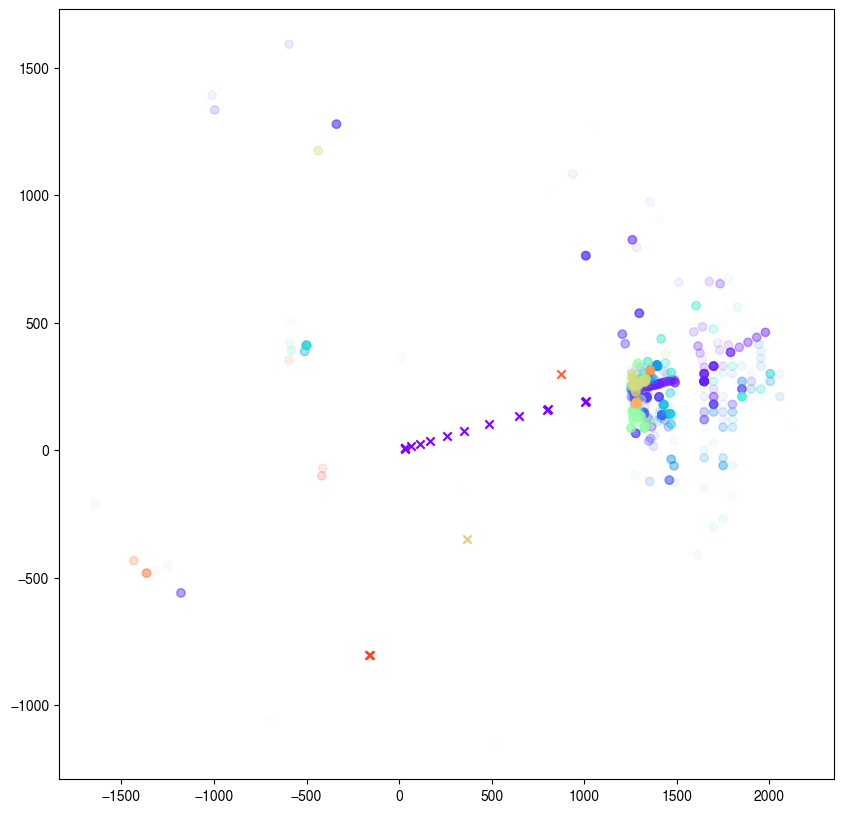

In [155]:
plot_event_particles(low_tracker_df, low_calo_contrib_df)

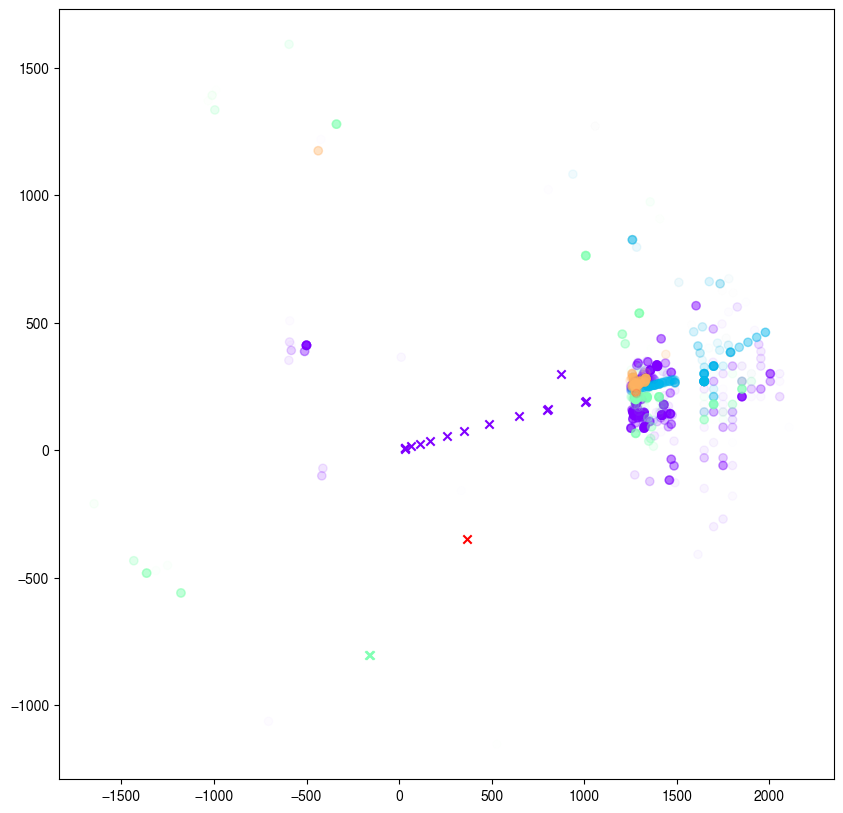

In [156]:
plot_event_particles(medium_tracker_df, medium_calo_contrib_df)

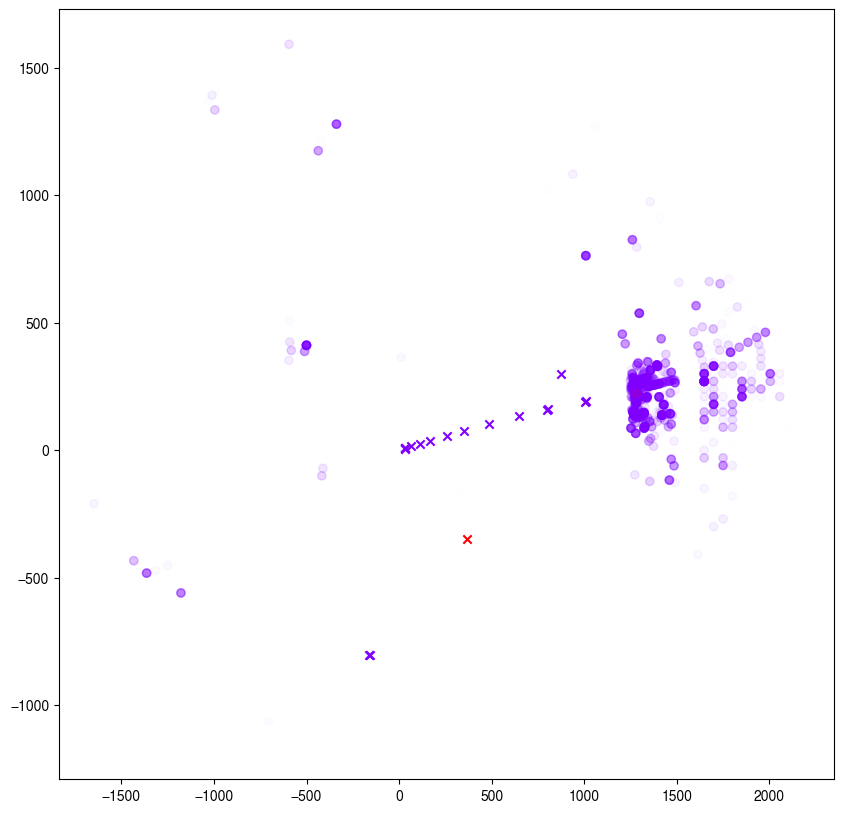

In [157]:
plot_event_particles(high_tracker_df, high_calo_contrib_df)

## Inspect EDM4hep files

In [9]:
from edm4hep_utils import ecal, hcal

In [10]:
low_threshold_events = uproot.open(low_threshold_edm4hep_file)["events"]
medium_threshold_events = uproot.open(medium_threshold_edm4hep_file)["events"]
high_threshold_events = uproot.open(high_threshold_edm4hep_file)["events"]
low_threshold_events.keys()
medium_threshold_events.keys()
high_threshold_events.keys()


NameError: name 'medium_threshold_edm4hep_file' is not defined

In [14]:
low_threshold_events["MCParticles/MCParticles.simulatorStatus"].arrays()

<Array [{...}, {...}, {...}, ..., {...}, {...}] type='10 * {"MCParticles.si...'>

In [60]:
ecal

['ECalBarrelCollection', 'ECalEndcapCollection']

In [43]:
hcal

['HCalBarrelCollection', 'HCalEndcapCollection']

In [49]:
all_calos = ecal + hcal

for key in all_calos:
    print(key)
    print(low_threshold_events[f"{key}Contributions/{key}Contributions.energy"].arrays()[0])

ECalBarrelCollection
{'ECalBarrelCollectionContributions.energy': []}
ECalEndcapCollection
{'ECalEndcapCollectionContributions.energy': []}
HCalBarrelCollection
{'HCalBarrelCollectionContributions.energy': []}
HCalEndcapCollection
{'HCalEndcapCollectionContributions.energy': [3.73e-05, ..., 0.000189]}


In [50]:
all_calos = ecal + hcal

for key in all_calos:
    print(key)
    print(medium_threshold_events[f"{key}Contributions/{key}Contributions.energy"].arrays()[0])

ECalBarrelCollection
{'ECalBarrelCollectionContributions.energy': []}
ECalEndcapCollection
{'ECalEndcapCollectionContributions.energy': []}
HCalBarrelCollection
{'HCalBarrelCollectionContributions.energy': []}
HCalEndcapCollection
{'HCalEndcapCollectionContributions.energy': [3.73e-05, ..., 0.000189]}


In [52]:
all_calos = ecal + hcal

for key in all_calos:
    print(key)
    print(high_threshold_events[f"{key}Contributions/{key}Contributions.energy"].arrays()[0])

ECalBarrelCollection
{'ECalBarrelCollectionContributions.energy': []}
ECalEndcapCollection
{'ECalEndcapCollectionContributions.energy': []}
HCalBarrelCollection
{'HCalBarrelCollectionContributions.energy': []}
HCalEndcapCollection
{'HCalEndcapCollectionContributions.energy': [3.73e-05, ..., 0.000189]}


## Hand-collapsed Particles

In [158]:
def plot_event_display(tracker_df, particles_df, parents_df, calo_contrib_df=None, calo_hits_df=None, use_all_particles=False, figsize=(14, 10)):
    """
    Create an event display showing tracker hits, particle vertices, and parent-daughter relationships.
    
    Parameters:
    -----------
    tracker_df : pandas.DataFrame
        DataFrame containing tracker hit information with columns: particle_id, x, y
    particles_df : pandas.DataFrame
        DataFrame containing particle information with columns: PDG, vx, vy, parents_begin, parents_end, p
    parents_df : pandas.DataFrame
        DataFrame containing parent-child relationships with column: particle_id
    calo_contrib_df : pandas.DataFrame, optional
        DataFrame containing calorimeter contribution information with columns: particle_id, x, y, energy
    calo_hits_df : pandas.DataFrame, optional
        DataFrame containing calorimeter hit information with column: energy
    figsize : tuple, optional
        Figure size as (width, height) in inches
        
    Returns:
    --------
    fig, ax : matplotlib Figure and Axes objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    if use_all_particles:
        unique_particles = range(len(particles_df))
    else:
        unique_particles = set(tracker_df.particle_id.unique())
        if calo_contrib_df is not None:
            unique_particles = unique_particles | set(calo_contrib_df.particle_id.unique())
    
    # Use a discrete colormap with distinct colors instead of rainbow
    # This will make it easier to distinguish between different particles
    distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', 
                      '#ffff33', '#a65628', '#f781bf', '#999999', '#66c2a5', 
                      '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']

    # Define a set of distinct markers to cycle through
    distinct_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '1', '2']
                      
    # First cycle through all colors with the same marker, then move to the next marker
    # This gives us len(distinct_colors) * len(distinct_markers) unique combinations
    color_idx = [i % len(distinct_colors) for i in range(len(unique_particles))]
    marker_idx = [i // len(distinct_colors) % len(distinct_markers) for i in range(len(unique_particles))]

    colors = [distinct_colors[color_idx[i]] for i in range(len(unique_particles))]
    markers = [distinct_markers[marker_idx[i]] for i in range(len(unique_particles))]

    # Determine the maximum energy for normalization
    max_energy = 1.0
    if calo_hits_df is not None and not calo_hits_df.empty:
        max_energy = calo_hits_df.energy.max()
    elif calo_contrib_df is not None and not calo_contrib_df.empty:
        max_energy = calo_contrib_df.energy.max()

    for i, particle_id in enumerate(unique_particles):
        # Plot tracker hits
        particle_hits = tracker_df[tracker_df.particle_id == particle_id]
        if not particle_hits.empty:
            ax.scatter(particle_hits.x, 
                       particle_hits.y, 
                       color=colors[i], 
                       marker=markers[i],
                       label=f"Particle {particle_id} hits")
        
        # Plot calorimeter hits
        if calo_contrib_df is not None and particle_id in calo_contrib_df.particle_id.unique():
            particle_calo = calo_contrib_df[calo_contrib_df.particle_id == particle_id]
            alphas = np.sqrt(particle_calo.energy / max_energy)
            ax.scatter(particle_calo.x, 
                      particle_calo.y, 
                      color=colors[i], 
                      marker=markers[i], 
                      alpha=alphas)

        # Get particle name from PDG ID if particle exists in particles_df
        if particle_id < len(particles_df):
            try:
                particle_name = Particle.from_pdgid(particles_df.iloc[particle_id].PDG).name
                ax.text(particles_df.iloc[particle_id].vx - 10, 
                        particles_df.iloc[particle_id].vy + 10, 
                        particle_name, 
                        fontsize=12, 
                        ha="center", 
                        va="center")
                ax.scatter(particles_df.iloc[particle_id].vx, 
                          particles_df.iloc[particle_id].vy, 
                          color=colors[i], 
                          label=f"Particle {particle_id} vertex, type {particle_name}, energy {particles_df.iloc[particle_id].p:.1f} GeV @ {particles_df.iloc[particle_id].vx:.2f} {particles_df.iloc[particle_id].vy:.2f}", 
                          marker='X',  # Use a distinct marker for vertices
                          s=100)

                # Add edges between parent and daughter vertices
                for parent_idx in range(int(particles_df.iloc[particle_id].parents_begin), int(particles_df.iloc[particle_id].parents_end)):
                    if parent_idx < len(parents_df):
                        parent_id = parents_df.iloc[parent_idx]['particle_id']
                        if parent_id < len(particles_df):
                            parent_vx = particles_df.iloc[parent_id].vx
                            parent_vy = particles_df.iloc[parent_id].vy
                            ax.plot([parent_vx, particles_df.iloc[particle_id].vx], 
                                   [parent_vy, particles_df.iloc[particle_id].vy], 
                                   color=colors[i])
            except Exception as e:
                print(f"Error processing particle {particle_id}: {e}")

    # Place legend outside the plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title('Particle Tracks with Parent-Daughter Relationships')
    
    return fig, ax


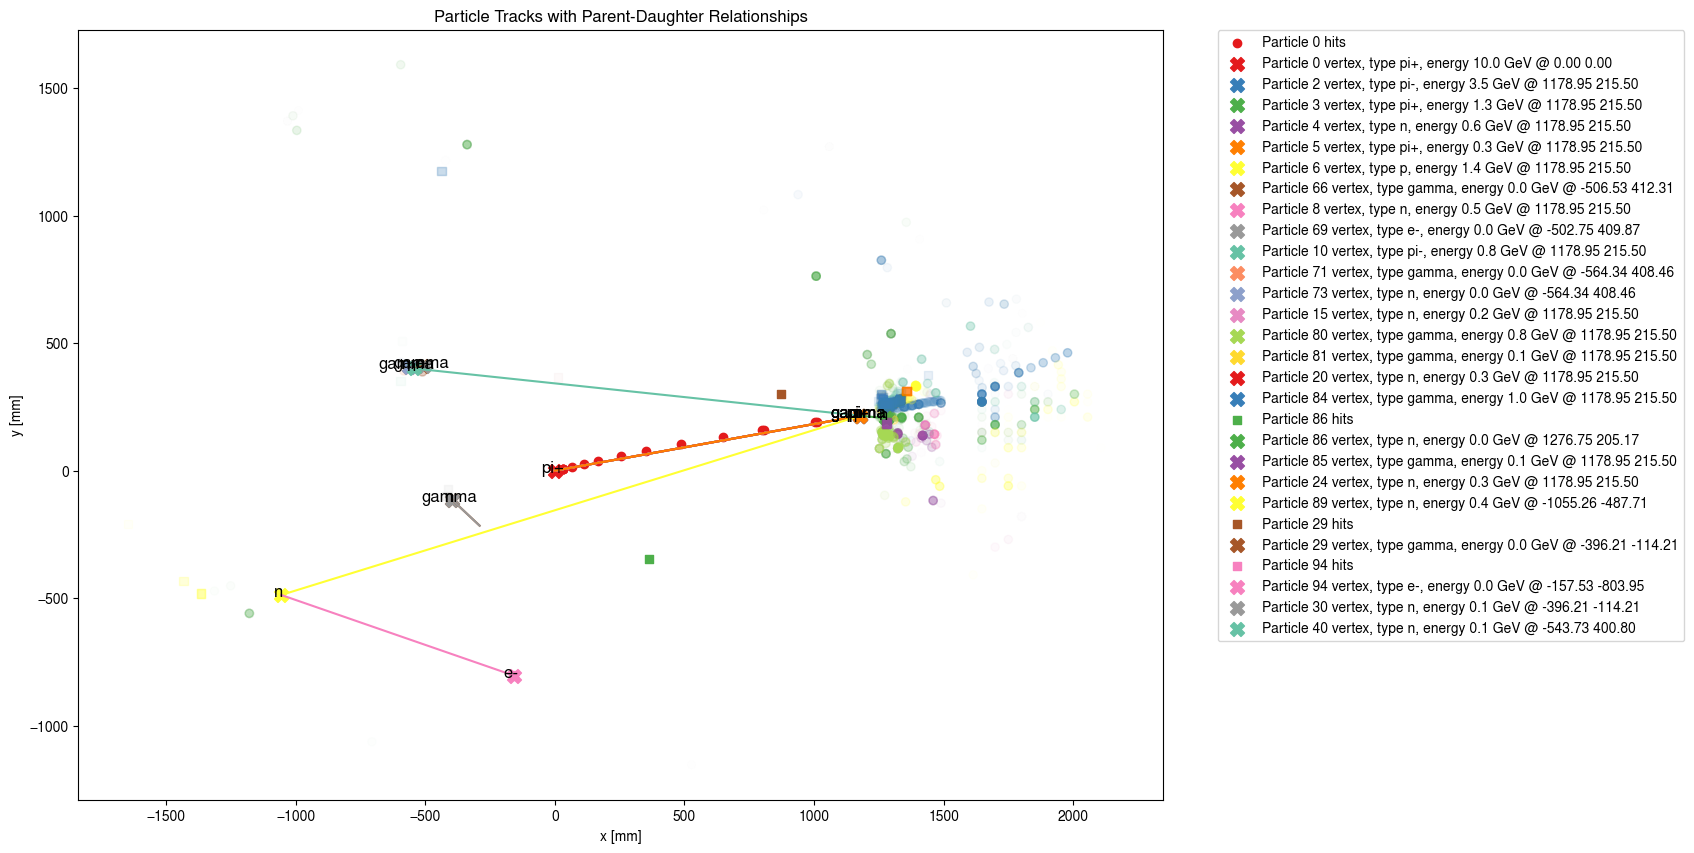

In [109]:
# Example usage:
fig, ax = plot_event_display(
    tracker_df=low_tracker_df,
    particles_df=low_particles_df,
    parents_df=low_parents_df,
    calo_contrib_df=low_calo_contrib_df,
    calo_hits_df=low_calo_hits_df
)
plt.show()


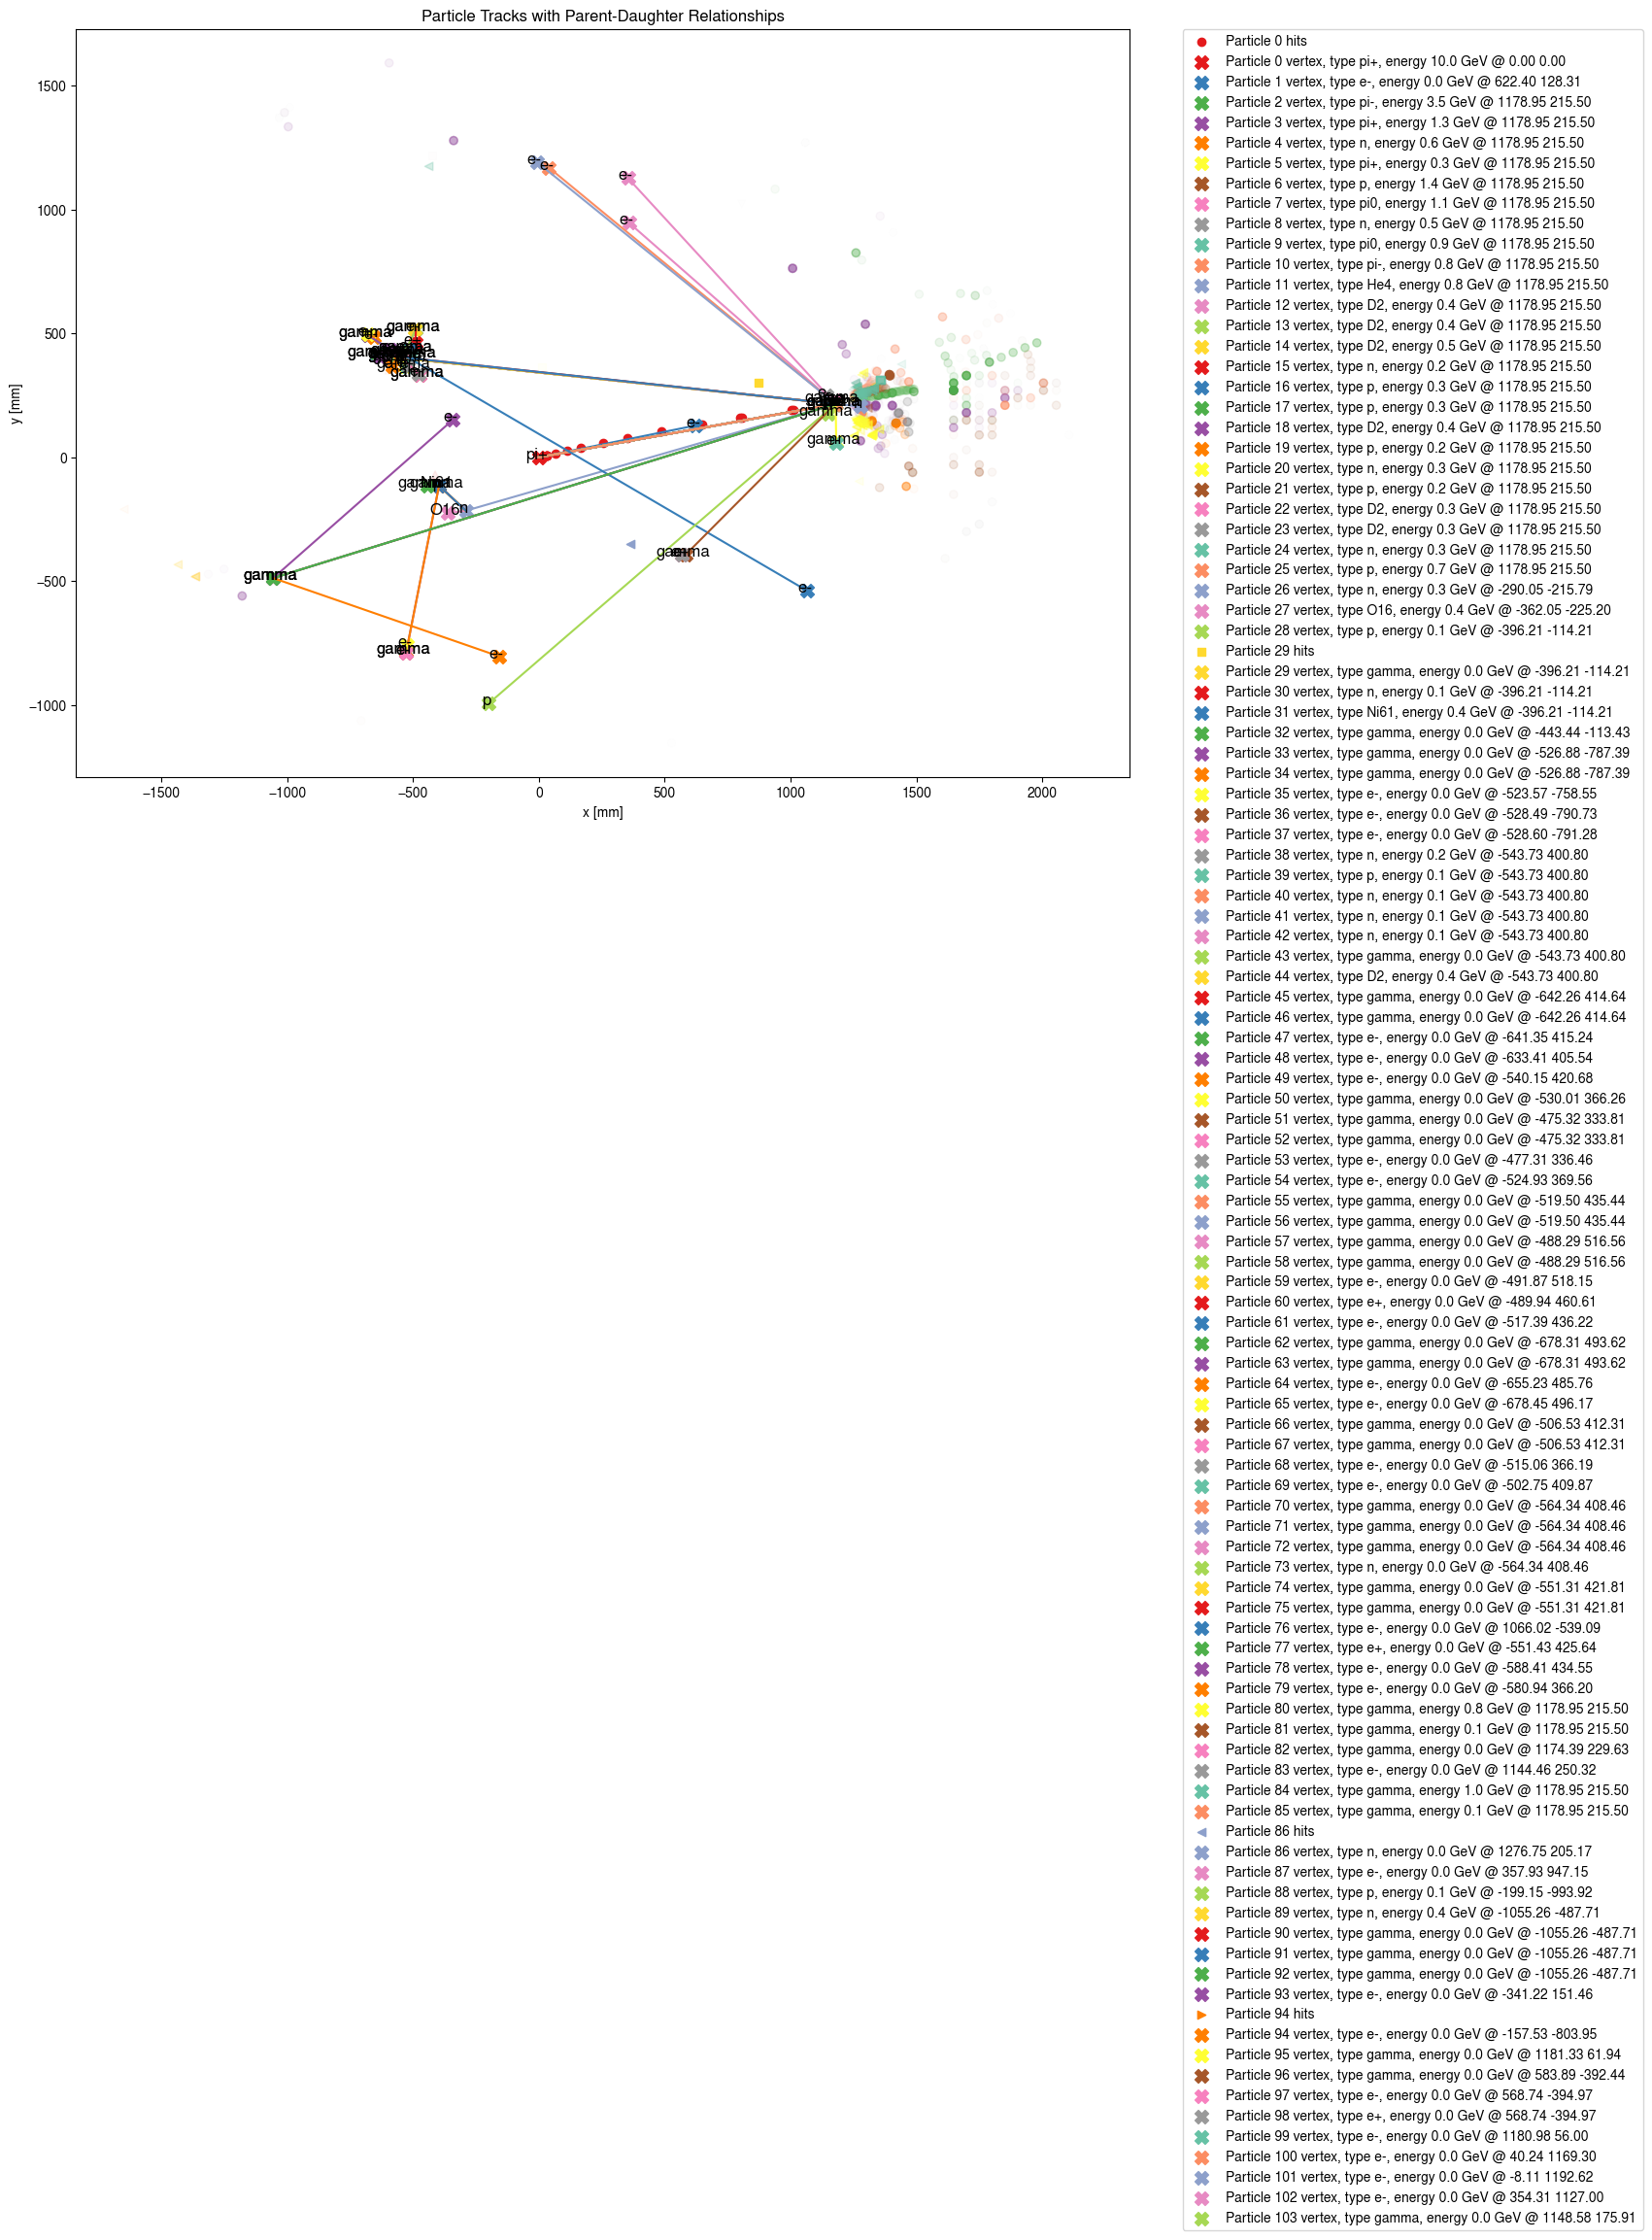

In [114]:
# Example usage:
fig, ax = plot_event_display(
    tracker_df=low_tracker_df,
    particles_df=low_particles_df,
    parents_df=low_parents_df,
    calo_contrib_df=low_calo_contrib_df,
    calo_hits_df=low_calo_hits_df,
    use_all_particles=True
)
plt.show()


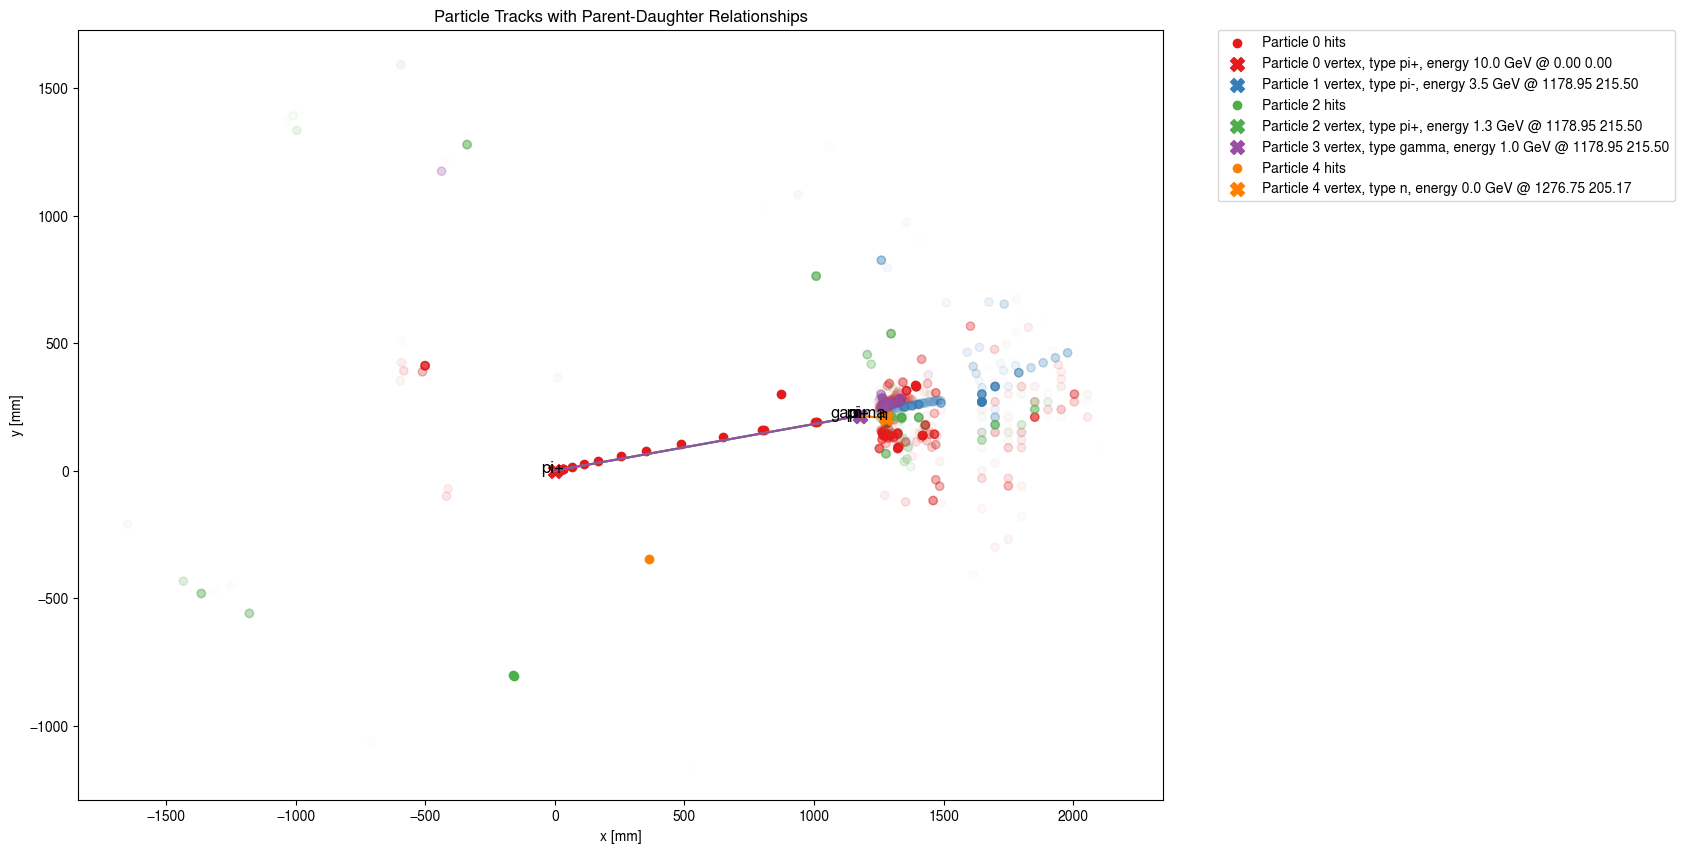

In [104]:
# Example usage:
fig, ax = plot_event_display(
    tracker_df=medium_tracker_df,
    particles_df=medium_particles_df,
    parents_df=medium_parents_df,
    calo_contrib_df=medium_calo_contrib_df,
    calo_hits_df=medium_calo_hits_df
)
plt.show()


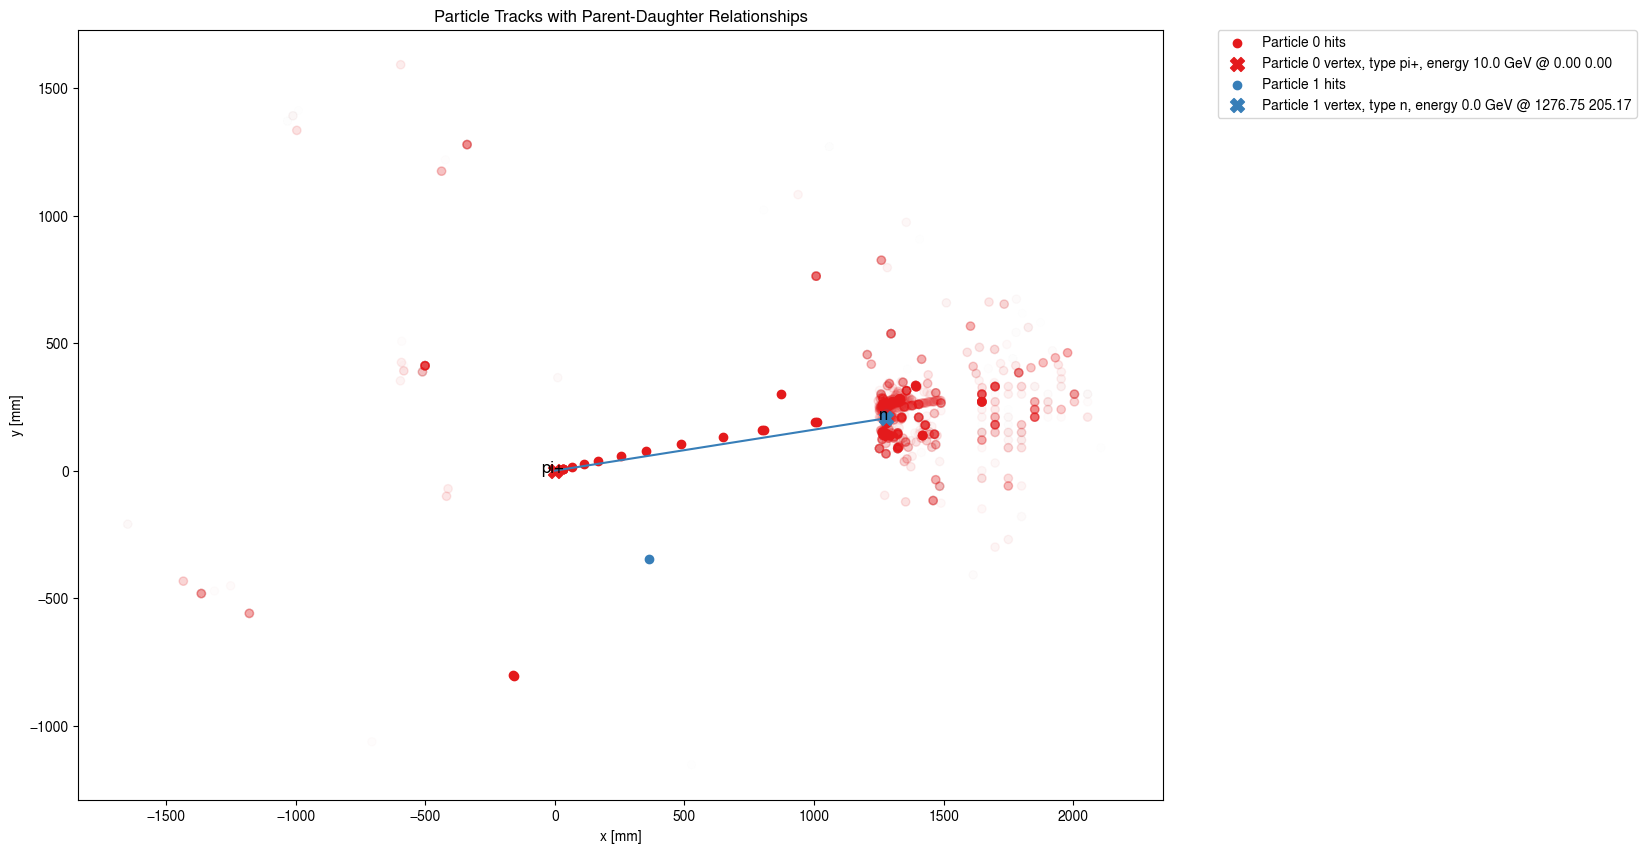

In [112]:
# Example usage:
fig, ax = plot_event_display(
    tracker_df=high_tracker_df,
    particles_df=high_particles_df,
    parents_df=high_parents_df,
    calo_contrib_df=high_calo_contrib_df,
    calo_hits_df=high_calo_hits_df,
    use_all_particles=True
)
plt.show()


In [60]:
low_tracker_df

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,R,phi,theta,eta,pt,detector
0,254331320730886,0.000040,0.120480,0.141009,0,-13.501595,29.070292,16.488254,-3.738657,8.068043,4.574327,0,32.052690,36.044937,2.005599,1.095687,0.494064,8.892180,PixelBarrelReadout
1,279757980109334,0.000038,0.255105,0.141168,0,-28.470300,61.658913,34.994946,-3.697103,8.079247,4.586715,0,67.914501,76.400430,2.003369,1.095000,0.494836,8.884976,PixelBarrelReadout
2,30651571441702,0.000063,0.426311,0.140904,0,-47.386166,103.155236,58.534447,-3.672920,8.089873,4.585884,0,113.518507,127.721309,2.001413,1.094717,0.495155,8.884616,PixelBarrelReadout
3,31815138480422,0.000033,0.432173,0.142947,0,-48.030576,104.576601,59.340007,-3.671713,8.090246,4.585948,0,115.079111,129.477559,2.001346,1.094711,0.495161,8.884456,PixelBarrelReadout
4,252955622644022,0.000042,0.640250,0.142093,0,-70.840642,155.091887,87.948935,-3.641432,8.103529,4.585450,0,170.504810,191.851258,1.999262,1.094577,0.495312,8.884099,PixelBarrelReadout
5,896514294222089,0.000098,0.970650,0.226071,0,-106.663110,235.446704,133.344556,-3.592540,8.123979,4.582850,0,258.480501,290.848655,1.996163,1.094527,0.495369,8.882870,ShortStripBarrelReadout
6,70948727972172313,0.000064,1.346760,0.226390,0,-146.874004,327.220822,185.033344,-3.537092,8.147702,4.582089,0,358.671771,403.587385,1.992696,1.094522,0.495374,8.882346,ShortStripBarrelReadout
7,1424219746081065,0.000062,1.870634,0.226365,0,-201.844276,455.497474,257.034984,-3.460118,8.178360,4.584187,0,498.215877,560.612204,1.987922,1.094501,0.495397,8.880202,ShortStripBarrelReadout
8,545787264966713,0.000055,2.482322,0.227239,0,-264.526406,605.938796,341.164615,-3.368453,8.215634,4.583579,0,661.162646,743.995524,1.982414,1.094425,0.495483,8.879365,ShortStripBarrelReadout
9,545787264966713,0.000195,2.482832,0.460742,1073741824,-264.733666,605.962914,341.269308,-0.000463,0.000047,0.000371,0,661.267697,744.136888,1.982687,1.094365,0.495551,0.000465,ShortStripBarrelReadout


In [81]:
np.sqrt(low_particles_df.vx**2 + low_particles_df.vy**2)

0       0.000000
1    1017.776309
2    1437.649302
dtype: float64

In [68]:
low_daughters_df

,particle_id,collectionID
0,1,2714477136
1,2,2714477136


In [69]:
low_parents_df

,particle_id,collectionID
0,0,2714477136
1,0,2714477136


## Question: Do any particles decay in the tracker, from a primary particle?

In [159]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV"
event_num = 0

In [160]:
low_threshold_edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"
low_threshold_event = load_edm4hep_file(low_threshold_edm4hep_file, event_num=event_num)

In [161]:
low_threshold_event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [6]:
low_tracker_df = low_threshold_event["tracker_df"]
low_parents_df = low_threshold_event["parents_df"]
low_particles_df = low_threshold_event["particles_df"]
low_daughters_df = low_threshold_event["daughters_df"]

In [7]:
low_parents_df

,particle_id,collectionID
0,0,2714477136
1,0,2714477136
2,0,2714477136
3,0,2714477136
4,0,2714477136
...,...,...
98,95,2714477136
99,3,2714477136
100,3,2714477136
101,3,2714477136


In [8]:
low_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,211,1,150994944,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,215.503582,-1053.953214,0,0,0,25,7.509689,10.000000,-0.793412,0.228517
1,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314567,-558.626150,0.002685,...,131.401366,-581.983508,0,1,25,25,0.003212,0.003374,-0.316664,0.580828
2,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,2.335005,...,306.682803,-1544.734026,1,2,25,25,2.396004,3.456059,-0.909041,0.226132
3,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,1.061720,...,205.171274,-1123.123427,2,3,25,38,1.067991,1.306458,-0.656411,-0.108426
4,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.548697,...,118.435793,-1018.249183,3,4,38,38,0.625221,0.635842,0.184068,-0.499952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,11,0,1493172224,-1.0,21.051262,0.000511,1180.984584,55.996198,-1338.326321,-0.000095,...,55.768974,-1337.425366,98,99,103,103,0.000601,0.001560,1.607024,-1.729773
100,11,0,1493172224,-1.0,32.093857,0.000511,40.244411,1169.299437,-687.859030,-0.000683,...,1171.264470,-686.715277,99,100,103,103,0.002097,0.002320,0.456166,1.902523
101,11,0,1493172224,-1.0,32.273067,0.000511,-8.106250,1192.619432,-685.637901,-0.002068,...,1192.132471,-685.777066,100,101,103,103,0.002146,0.002212,-0.247636,2.871881
102,11,0,1493172224,-1.0,2371.792969,0.000511,354.308557,1126.995840,-1355.059080,0.000104,...,1124.697051,-1357.129397,101,102,103,103,0.001653,0.003156,-1.262515,-1.507632


In [106]:
# Convert this float to a binary string
bin_str = bin(int(low_particles_df.iloc[0].simulatorStatus))[2:].zfill(32)
print(bin_str)
# Convert this binary string back to a float
float_val = int(bin_str, 2)
print(float_val)

# The first 7 bits encode this: simulator status bits: [sbvtcls]  s: created in simulation b: backscatter v: vertex is not endpoint of parent t: decayed in tracker c: decayed in calorimeter l: has left detector s: stopped o: overlay
# So, let's write a function that takes in a float and returns a dictionary with these bits
def get_simulator_status_bits(float_val):

    """
    This function takes in a float and returns a dictionary with the simulator status bits
    The binary string is padded to 32 bits, and we use this code from edm4hep.yaml as the guide:
    // define the bit positions for the simulation flag\n
      static const int BITCreatedInSimulation = 30;\n
      static const int BITBackscatter = 29 ;\n
      static const int BITVertexIsNotEndpointOfParent = 28 ;  \n
      static const int BITDecayedInTracker = 27 ; \n
      static const int BITDecayedInCalorimeter = 26 ;   \n
      static const int BITLeftDetector = 25 ;     \n
      static const int BITStopped = 24 ;    \n
      static const int BITOverlay = 23 ;    \n

    Therefore, the bit positions are:
    created_in_simulation: 30
    backscatter: 29
    vertex_not_endpoint: 28
    decayed_in_tracker: 27
    decayed_in_calorimeter: 26
    has_left_detector: 25

    and thus we need to skip the first bit (bit 31)
    """
    bin_str = bin(int(float_val))[2:].zfill(32)
    return {
        'created_in_simulation': bin_str[1],  # Bit 30
        'backscatter': bin_str[2],            # Bit 29
        'vertex_not_endpoint': bin_str[3],    # Bit 28
        'decayed_in_tracker': bin_str[4],     # Bit 27
        'decayed_in_calorimeter': bin_str[5], # Bit 26
        'has_left_detector': bin_str[6],      # Bit 25
        'stopped': bin_str[7],                # Bit 24
        'overlay': bin_str[8]                 # Bit 23
    }


00001001000000000000000000000000
150994944


In [107]:
for i in range(low_particles_df.shape[0]):
    print(f"Particle {i}: {Particle.from_pdgid(low_particles_df.iloc[i].PDG).name}, {low_particles_df.iloc[i].p:.3f} GeV")
    print(get_simulator_status_bits(low_particles_df.iloc[i].simulatorStatus))

Particle 0: pi+, 10.000 GeV
{'created_in_simulation': '0', 'backscatter': '0', 'vertex_not_endpoint': '0', 'decayed_in_tracker': '1', 'decayed_in_calorimeter': '0', 'has_left_detector': '0', 'stopped': '1', 'overlay': '0'}
Particle 1: e-, 0.003 GeV
{'created_in_simulation': '1', 'backscatter': '0', 'vertex_not_endpoint': '1', 'decayed_in_tracker': '1', 'decayed_in_calorimeter': '0', 'has_left_detector': '0', 'stopped': '1', 'overlay': '0'}
Particle 2: pi-, 3.456 GeV
{'created_in_simulation': '1', 'backscatter': '0', 'vertex_not_endpoint': '0', 'decayed_in_tracker': '0', 'decayed_in_calorimeter': '1', 'has_left_detector': '0', 'stopped': '1', 'overlay': '0'}
Particle 3: pi+, 1.306 GeV
{'created_in_simulation': '1', 'backscatter': '0', 'vertex_not_endpoint': '0', 'decayed_in_tracker': '0', 'decayed_in_calorimeter': '1', 'has_left_detector': '0', 'stopped': '1', 'overlay': '0'}
Particle 4: n, 0.636 GeV
{'created_in_simulation': '1', 'backscatter': '0', 'vertex_not_endpoint': '0', 'decayed

In [113]:
get_simulator_status_bits(low_particles_df.iloc[0].simulatorStatus)

{'created_in_simulation': '0',
 'backscatter': '0',
 'vertex_not_endpoint': '0',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '1',
 'overlay': '0'}

In [72]:
get_simulator_status_bits(low_particles_df.iloc[2].simulatorStatus)

{'created_in_simulation': '1',
 'backscatter': '1',
 'vertex_not_endpoint': '1',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '0',
 'overlay': '0'}

In [75]:
low_particles_df.iloc[1]

PDG                1.100000e+01
generatorStatus    0.000000e+00
simulatorStatus    1.493172e+09
charge            -1.000000e+00
time               3.821357e+00
mass               5.109989e-04
vx                -3.959678e+02
vy                 9.375916e+02
vz                 5.252609e+02
px                -1.341306e-03
py                 7.681124e-04
pz                 1.274417e-04
endpoint_x        -3.984029e+02
endpoint_y         9.369181e+02
endpoint_z         5.251611e+02
parents_begin      0.000000e+00
parents_end        1.000000e+00
daughters_begin    2.000000e+00
daughters_end      2.000000e+00
pt                 1.545671e-03
p                  1.550916e-03
eta                8.235763e-02
phi                2.621519e+00
Name: 1, dtype: float64

In [24]:
get_simulator_status_bits(low_particles_df.iloc[1].simulatorStatus)

{'created_in_simulation': '1',
 'backscatter': '0',
 'vertex_not_endpoint': '1',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '1',
 'overlay': '0'}

In [26]:
get_simulator_status_bits(low_particles_df.iloc[86].simulatorStatus)

{'created_in_simulation': '1',
 'backscatter': '1',
 'vertex_not_endpoint': '0',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '0',
 'overlay': '0'}

In [82]:
get_simulator_status_bits(low_particles_df.iloc[0].simulatorStatus)

{'created_in_simulation': '0',
 'backscatter': '0',
 'vertex_not_endpoint': '0',
 'decayed_in_tracker': '0',
 'decayed_in_calorimeter': '1',
 'has_left_detector': '0',
 'stopped': '1',
 'overlay': '0'}

In [115]:
# Want to find all particles that were emitted in the tracker from the primary particle
# 1. The primary particle is particle 0 (check this with vx, vy, vz)
# 2. Check if the primary particle decayed in the tracker (using simulatorStatus)
# 3. If it did, find all particles that have a parent with particle_id == 0
# 4. Check if any of these particles left a hit in the tracker (using tracker_df)

for event_num in range(10):
    print(f"--- Event {event_num} ---")
    low_threshold_edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"
    low_threshold_event = load_edm4hep_file(low_threshold_edm4hep_file, event_num=event_num)
    low_tracker_df = low_threshold_event["tracker_df"]
    low_parents_df = low_threshold_event["parents_df"]
    low_particles_df = low_threshold_event["particles_df"]

    print(f"Number of particles: {len(low_particles_df)}")

    # 1. Check that particle 0 is the primary particle
    if low_particles_df.iloc[0].vx == 0 and low_particles_df.iloc[0].vy == 0 and low_particles_df.iloc[0].vz == 0:
        print(f"Particle 0 is the primary particle")
    else:
        print(f"Particle 0 is not the primary particle")

    # 2. Check if the primary particle decayed in the tracker
    primary_particle_decayed = bool(int(get_simulator_status_bits(low_particles_df.iloc[0].simulatorStatus)["decayed_in_tracker"]))
    print(primary_particle_decayed)
    if primary_particle_decayed:
        print(f"The primary particle decayed in the tracker")
    else:
        print(f"The primary particle did not decay in the tracker")

    # 3. Find all particles that have a parent with particle_id == 0
    particles_with_parent_0 = low_particles_df[low_particles_df.apply(lambda x: np.isin(range(int(x.parents_begin), int(x.parents_end)), low_parents_df[low_parents_df.particle_id == 0].index).any(), axis=1)]
    print(f"There are {len(particles_with_parent_0)} particles that have a parent with particle_id == 0")

    # 4. Check if any of these particles left a hit in the tracker
    particles_with_tracker_hits = particles_with_parent_0[particles_with_parent_0.index.isin(low_tracker_df.particle_id)]
    print(f"There are {len(particles_with_tracker_hits)} particles that left a hit in the tracker")

--- Event 0 ---
Number of particles: 104
Particle 0 is the primary particle
True
The primary particle decayed in the tracker
There are 25 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 1 ---
Number of particles: 17
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 11 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 2 ---
Number of particles: 37
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 27 particles that have a parent with particle_id == 0
There are 1 particles that left a hit in the tracker
--- Event 3 ---
Number of particles: 3
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 2 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 4 ---


In [162]:
# Want to find all particles that were emitted in the tracker from the primary particle
# 1. The primary particle is particle 0 (check this with vx, vy, vz)
# 2. Check if the primary particle decayed in the tracker (using simulatorStatus)
# 3. If it did, find all particles that have a parent with particle_id == 0
# 4. Check if any of these particles left a hit in the tracker (using tracker_df)

for event_num in range(10):
    print(f"--- Event {event_num} ---")
    high_threshold_edm4hep_file = f"{base_dir}/single_run_test_high_threshold/edm4hep.root"
    high_threshold_event = load_edm4hep_file(high_threshold_edm4hep_file, event_num=event_num)
    high_tracker_df = high_threshold_event["tracker_df"]
    high_parents_df = high_threshold_event["parents_df"]
    high_particles_df = high_threshold_event["particles_df"]

    print(f"Number of particles: {len(high_particles_df)}")

    # 1. Check that particle 0 is the primary particle
    if high_particles_df.iloc[0].vx == 0 and high_particles_df.iloc[0].vy == 0 and high_particles_df.iloc[0].vz == 0:
        print(f"Particle 0 is the primary particle")
    else:
        print(f"Particle 0 is not the primary particle")

    # 2. Check if the primary particle decayed in the tracker
    primary_particle_decayed = bool(int(get_simulator_status_bits(high_particles_df.iloc[0].simulatorStatus)["decayed_in_tracker"]))
    print(primary_particle_decayed)
    if primary_particle_decayed:
        print(f"The primary particle decayed in the tracker")
    else:
        print(f"The primary particle did not decay in the tracker")

    # 3. Find all particles that have a parent with particle_id == 0
    particles_with_parent_0 = high_particles_df[high_particles_df.apply(lambda x: np.isin(range(int(x.parents_begin), int(x.parents_end)), high_parents_df[high_parents_df.particle_id == 0].index).any(), axis=1)]
    print(f"There are {len(particles_with_parent_0)} particles that have a parent with particle_id == 0")

    # 4. Check if any of these particles left a hit in the tracker
    particles_with_tracker_hits = particles_with_parent_0[particles_with_parent_0.index.isin(high_tracker_df.particle_id)]
    print(f"There are {len(particles_with_tracker_hits)} particles that left a hit in the tracker")

--- Event 0 ---
Number of particles: 2
Particle 0 is the primary particle
True
The primary particle decayed in the tracker
There are 1 particles that have a parent with particle_id == 0
There are 1 particles that left a hit in the tracker
--- Event 1 ---
Number of particles: 1
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 0 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 2 ---
Number of particles: 1
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 0 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 3 ---
Number of particles: 1
Particle 0 is the primary particle
False
The primary particle did not decay in the tracker
There are 0 particles that have a parent with particle_id == 0
There are 0 particles that left a hit in the tracker
--- Event 4 ---
Number 

In [32]:
low_particles_df[low_particles_df.apply(lambda x: np.isin(range(int(x.parents_begin), int(x.parents_end)), low_parents_df[low_parents_df.particle_id == 0].index).any(), axis=1)]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
1,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314567,-558.626150,0.002685,...,131.401366,-581.983508,0,1,25,25,0.003212,0.003374,-0.316664,0.580828
2,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,2.335005,...,306.682803,-1544.734026,1,2,25,25,2.396004,3.456059,-0.909041,0.226132
3,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,1.061720,...,205.171274,-1123.123427,2,3,25,38,1.067991,1.306458,-0.656411,-0.108426
4,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.548697,...,118.435793,-1018.249183,3,4,38,38,0.625221,0.635842,0.184068,-0.499952
5,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,0.241274,...,286.017507,-1186.823333,4,5,38,38,0.252204,0.304445,-0.633020,0.295490
6,2212,0,1157627904,1.0,5.325320,0.938272,1178.951708,215.503582,-1053.953214,0.969796,...,284.530240,-1229.317751,5,6,38,38,1.039124,1.374043,-0.782744,0.367351
7,111,0,1207959552,0.0,5.325320,0.134977,1178.951708,215.503582,-1053.953214,0.679387,...,215.503591,-1053.953243,6,7,38,40,0.725722,1.104399,-0.981666,0.359273
8,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.434327,...,158.318630,-1228.786742,7,8,40,40,0.445718,0.540712,-0.641807,-0.226569
9,111,0,1207959552,0.0,5.325320,0.134977,1178.951708,215.503582,-1053.953214,0.632778,...,215.503512,-1053.953292,8,9,40,42,0.768363,0.907587,-0.593252,-0.603172
10,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,0.401523,...,282.396989,-1264.010832,9,10,42,51,0.454572,0.766911,-1.113798,0.487940


In [23]:
low_particles_df[(low_particles_df.parents_begin >= 0) & (low_particles_df.parents_end <= 24)]


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,211,1,150994944,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,215.503582,-1053.953214,0,0,0,25,7.509689,10.000000,-0.793412,0.228517
1,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314567,-558.626150,0.002685,...,131.401366,-581.983508,0,1,25,25,0.003212,0.003374,-0.316664,0.580828
2,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,2.335005,...,306.682803,-1544.734026,1,2,25,25,2.396004,3.456059,-0.909041,0.226132
3,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,1.061720,...,205.171274,-1123.123427,2,3,25,38,1.067991,1.306458,-0.656411,-0.108426
4,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.548697,...,118.435793,-1018.249183,3,4,38,38,0.625221,0.635842,0.184068,-0.499952
5,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503582,-1053.953214,0.241274,...,286.017507,-1186.823333,4,5,38,38,0.252204,0.304445,-0.633020,0.295490
6,2212,0,1157627904,1.0,5.325320,0.938272,1178.951708,215.503582,-1053.953214,0.969796,...,284.530240,-1229.317751,5,6,38,38,1.039124,1.374043,-0.782744,0.367351
7,111,0,1207959552,0.0,5.325320,0.134977,1178.951708,215.503582,-1053.953214,0.679387,...,215.503591,-1053.953243,6,7,38,40,0.725722,1.104399,-0.981666,0.359273
8,2112,0,1157627904,0.0,5.325320,0.939565,1178.951708,215.503582,-1053.953214,0.434327,...,158.318630,-1228.786742,7,8,40,40,0.445718,0.540712,-0.641807,-0.226569
9,111,0,1207959552,0.0,5.325320,0.134977,1178.951708,215.503582,-1053.953214,0.632778,...,215.503512,-1053.953292,8,9,40,42,0.768363,0.907587,-0.593252,-0.603172


In [25]:
low_tracker_df

,cellID,EDep,time,pathLength,quality,x,y,z,px,py,pz,particle_id,r,R,phi,theta,eta,pt,detector
0,10997633253382,0.000046,0.143050,0.167380,0,31.313939,7.240239,-28.260180,7.319360,1.682778,-6.602227,0,32.140066,42.797448,0.227222,2.292046,-0.793388,7.510312,PixelBarrelReadout
1,9687668228358,0.000042,0.147953,0.173594,0,32.448207,7.500762,-29.283262,7.319657,1.681203,-6.601789,0,33.303868,44.347007,0.227171,2.292043,-0.793383,7.510248,PixelBarrelReadout
2,249177578012950,0.000062,0.302190,0.167145,0,66.250578,15.215565,-59.748868,7.324624,1.661593,-6.599766,0,67.975382,90.501822,0.225752,2.291875,-0.793160,7.510726,PixelBarrelReadout
3,11269390533158,0.000046,0.508585,0.168126,0,111.588953,25.423328,-100.590262,7.329116,1.636143,-6.599785,0,114.448417,152.370735,0.224007,2.291839,-0.793111,7.509521,PixelBarrelReadout
4,43017318957878,0.000055,0.758126,0.168246,0,166.447468,37.540911,-149.978514,7.334657,1.602737,-6.600558,0,170.628485,227.173137,0.221830,2.291874,-0.793159,7.507726,PixelBarrelReadout
5,9687668228358,0.000021,0.147912,0.078876,1073741824,32.394304,7.491571,-29.282581,-0.000169,-0.000143,-0.000758,0,33.249279,44.305576,0.227267,2.292845,-0.794451,0.000222,PixelBarrelReadout
6,4189757767942,0.000065,0.165217,0.233655,1073741824,32.965128,6.582458,-33.248635,0.000431,0.000016,-0.000167,0,33.615895,47.281076,0.197087,2.350702,-0.873627,0.000431,PixelBarrelReadout
7,71565940542144777,0.000071,1.168205,0.271665,0,256.684054,56.904351,-231.099534,7.345233,1.548243,-6.598343,0,262.915973,350.045431,0.218162,2.291880,-0.793166,7.506631,ShortStripBarrelReadout
8,351633267950105,0.000107,1.597078,0.268385,0,351.246436,76.453148,-315.975668,7.355785,1.491108,-6.597908,0,359.470642,478.601886,0.214320,2.291889,-0.793178,7.505397,ShortStripBarrelReadout
9,71951096029250345,0.000072,2.211591,0.267508,0,486.984105,103.195472,-437.601316,7.371936,1.409538,-6.595852,0,497.797975,662.795395,0.208818,2.291929,-0.793232,7.505480,ShortStripBarrelReadout


Take-away, we can absolutely say that AT LEAST ONE particle was emitted in the tracker from the primary particle. But in this case it didn't leave a hit... 